# Project Description


## Project Motivation

The foreign exchange market is the world's largest financial market, trading over **$7.5 trillion per day**. The Efficient Market Hypothesis (EMH) suggests that all publicly available information is already priced in, making consistent profit from price patterns alone impossible. This project asks a fundamental academic question: **can machine learning models extract statistically significant predictive signal from high-frequency forex price noise?** We tackle this using USD/CHF 1-minute OHLC data, a notoriously noisy and mean-reverting instrument.


## Target Definition

We formulate this as a **regression task** predicting the log-return:

$$
y_t = \ln\left(\frac{P_{t+1}}{P_t}\right)
$$

where $P_t$ is the close price at minute $t$. Log-returns are preferred over absolute prices because they are approximately stationary, scale-invariant, and naturally handle compounding. In contrast, our v1 attempt using raw absolute price targets produced catastrophic results ($R^2 = -3.26$), confirming that price levels are non-stationary and unsuitable for direct regression.


## Dataset

- **Source**: [histdata.com](https://www.histdata.com/) — 1-minute OHLC (Open, High, Low, Close) ticks
- **Period**: January 2020 – June 2026
- **Rows**: ~2.3 million
- **Schema**:

| Column | Type | Description |
|--------|------|-------------|
| `timestamp` | datetime | Minute-level index (UTC) |
| `open` | float64 | Opening price |
| `high` | float64 | Period high |
| `low` | float64 | Period low |
| `close` | float64 | Closing price |
| `spread` | int64 | Bid-ask spread in pips |
| `volume` | int64 | Tick volume |

No missing timestamps in the raw data. All times aligned to UTC minute boundaries.


## Time Series Characteristics

The USD/CHF pair exhibits four distinct regimes over the 6.5-year window:

1. **Bullish (2020–2021)** — USD strengthened post-COVID, risk-off flows into dollar. Trend up.
2. **Sideways (2022–2024)** — Range-bound consolidation. Low volatility, mean-reverting.
3. **Bullish (early 2025)** — Renewed USD strength, breakout from the range.
4. **Bearish (late 2025–2026)** — USD weakening, CHF safe-haven inflows dominate.

These regime shifts test model robustness — a model trained only on one regime may fail on another.


## Feature Engineering

We construct **34 features** organized into 4 families:

| Family | Count | Description |
|--------|-------|-------------|
| **Lags** | 8 | Log-return lags at t-1 through t-8 |
| **Rolling Stats** | 16 | Rolling mean, std, min, max over windows of [5, 15, 30, 60] minutes |
| **Price-Derived** | 4 | Spread, high-low range, volume, OHLC mean |
| **Technical Indicators** | 6 | RSI(14), MACD, MACD signal, MACD hist, BB upper, BB lower |

All features are computed from the OHLCV raw columns with a **look-ahead-free** rolling window to prevent data leakage.


## Experimental Design

We use a strict **chronological (time-series) split** to avoid look-ahead bias:

| Split | Date Range | Rows | % of Total |
|-------|------------|------|------------|
| **Train** | < 2025-01-01 | ~1,800,000 | ~78% |
| **Validation** | 2025-01 to 2025-09 | ~247,000 | ~11% |
| **Test** | >= 2025-09 | ~276,000 | ~11% |

No shuffling. The validation and test sets are entirely out-of-sample (future unseen data from the model's perspective).


## Three Models

We compare three distinct model families:

1. **MLP (Multi-Layer Perceptron)** — A deep neural network with architecture **34 → 1024 → 512 → 256 → 128 → 1**. ReLU activations, trained with Adam, GPU-accelerated via PyTorch. 5 hidden layers of decreasing width to progressively distill features.

2. **KNN (K-Nearest Neighbors)** — A lazy learner that retrieves the k most similar historical patterns. GPU-batched `cdist` from CuPy/CUDA for efficient distance computation over 1.8M training samples.

3. **XGBoost** — Gradient boosted decision trees. Uses ROCm GPU acceleration (`tree_method='hist'`, `device='cuda'`). Handles non-linear interactions well and is robust to outliers.

All models share the same 34 features and train/val/test splits for fair comparison.


## Evaluation Framework

We report **five metrics** across all models and scenarios:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i-\hat{y}_i)^2}$ | Root mean squared error — standard deviation of residuals |
| **MAE** | $\frac{1}{n}\sum|y_i-\hat{y}_i|$ | Mean absolute error — average magnitude of error |
| **R²** | $1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$ | Variance explained. In forex, **R² ≈ 0 is the realistic baseline** (no signal) |
| **MAPE** | $\frac{100\%}{n}\sum|\frac{y_i-\hat{y}_i}{y_i}|$ | Mean absolute percentage error |
| **DirAcc** | $\frac{1}{n}\sum\mathbb{1}_{\text{sign}(y_i)=\text{sign}(\hat{y}_i)}$ | Direction accuracy. **> 50% indicates directional signal** |

Given the efficient market hypothesis for major forex pairs, an R² slightly above zero or DirAcc meaningfully above 50% would represent a non-trivial finding.


## Three Experimental Scenarios

We conduct three systematic experiments to understand model behavior:

1. **Hyperparameter Tuning** — Grid and random search over key parameters for each model (learning rate, layer width for MLP; k, distance metric for KNN; n_estimators, max_depth, learning_rate for XGBoost). Validated on the validation set.

2. **Feature Ablation** — Train each model on subsets of feature families (lags only, rolling only, technicals only, all-but-one) to measure each family's contribution to predictive performance.

3. **Training Size Sensitivity** — Train models on progressively larger fractions of the training data (10%, 25%, 50%, 75%, 100%) to analyze learning curves and data efficiency.


## Reproducibility

This project is fully reproducible:

- **GitHub**: [Samubrine/fp-ml](https://github.com/Samubrine/fp-ml) — complete source code and notebooks
- **Self-contained**: Single Jupyter notebook with all preprocessing, training, and evaluation steps in order
- **Hardware**: Runs in ~30 minutes on an **AMD RX 9060 XT** GPU with **ROCm 7.2.4**
- **Seed**: Fixed random seed (42) for all stochastic operations
- **Environment**: `requirements.txt` and `environment.yml` pin every dependency version


### Exploratory Data Analysis
#### Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, silhouette_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os
import time
import gc
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# Ensure output directories exist
os.makedirs('outputs/preprocessed', exist_ok=True)
os.makedirs('outputs/models', exist_ok=True)
os.makedirs('outputs/plots', exist_ok=True)

# Device Configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

(null): No such file or directory


Using device: cuda


(null): No such file or directory


#### Load Raw Data

In [2]:
CSV_PATH = 'data/processed/USDCHF_1min_2020_2026.csv'
t0 = time.time()
df = pd.read_csv(CSV_PATH)
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime').sort_index()
df.drop(columns=['volume', 'tick_volume', 'spread'], errors='ignore', inplace=True)
print(f'Loaded {len(df):,} rows in {time.time()-t0:.1f}s')
print(f'Range: {df.index.min()} : {df.index.max()}')

Loaded 2,319,765 rows in 1.1s
Range: 2020-01-01 17:04:00 : 2026-05-29 16:58:00


#### Missing Values Pattern

Missing values in 1-minute forex data are **structural, not random**. The forex market operates 24/5 — it closes from Friday evening (New York close) to Sunday evening (Sydney open). During these weekend gaps, no data is generated. Additionally, there may be gaps around major holidays or low-liquidity periods.

Because the data is indexed by time, `.resample()` or `.asfreq()` would introduce NaN rows for these non-trading periods. The missing values are therefore expected and should be handled with forward-fill (`.ffill()`), interpolation, or simply dropped, depending on the downstream model's requirements.

In [3]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().mean() * 100).round(4)
missing_report = pd.DataFrame({'Missing': null_counts, 'Percent': null_pct})
print("Missing Values Report:")
print(missing_report)


Missing Values Report:
       Missing  Percent
open         0      0.0
high         0      0.0
low          0      0.0
close        0      0.0


#### Descriptive Statistics

In [4]:
print("Descriptive Statistics:")
print(df.describe().T)

Descriptive Statistics:
           count      mean       std      min      25%      50%      75%  \
open   2319765.0  0.895154  0.056023  0.76057  0.86864  0.90600  0.92728   
high   2319765.0  0.895220  0.056029  0.76074  0.86872  0.90606  0.92736   
low    2319765.0  0.895087  0.056017  0.76040  0.86857  0.90595  0.92721   
close  2319765.0  0.895154  0.056023  0.76056  0.86864  0.90600  0.92728   

           max  
open   1.01470  
high   1.01472  
low    1.01452  
close  1.01470  


#### Full Period Price Series

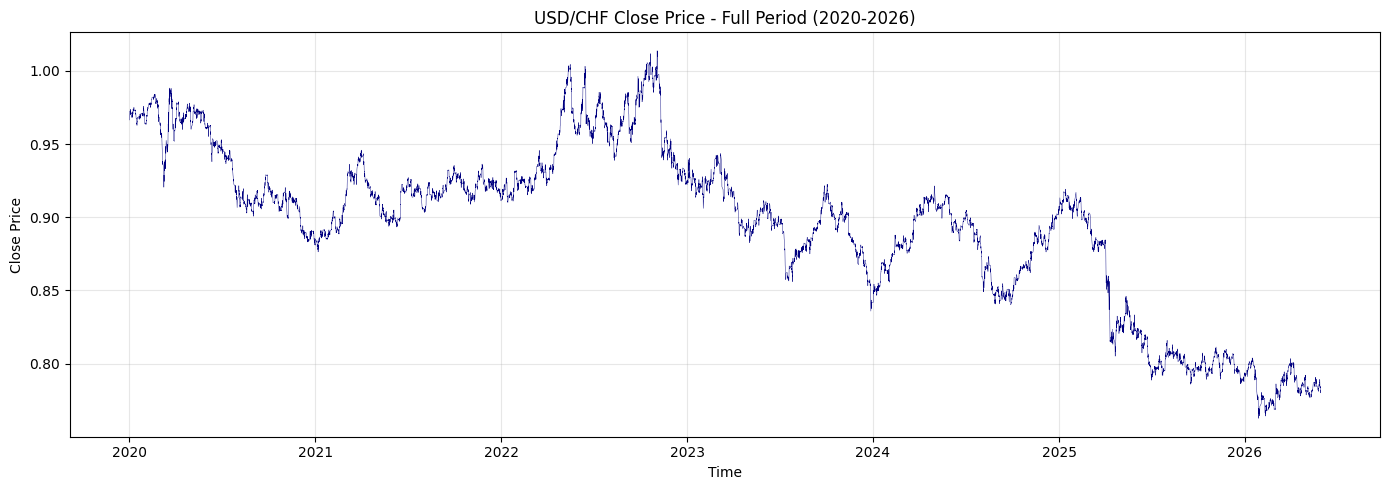

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(df['close'].iloc[::200], linewidth=0.3, color='navy')
plt.title('USD/CHF Close Price - Full Period (2020-2026)')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/plots/full_period_price.png')
plt.show()

#### One Year Zoom

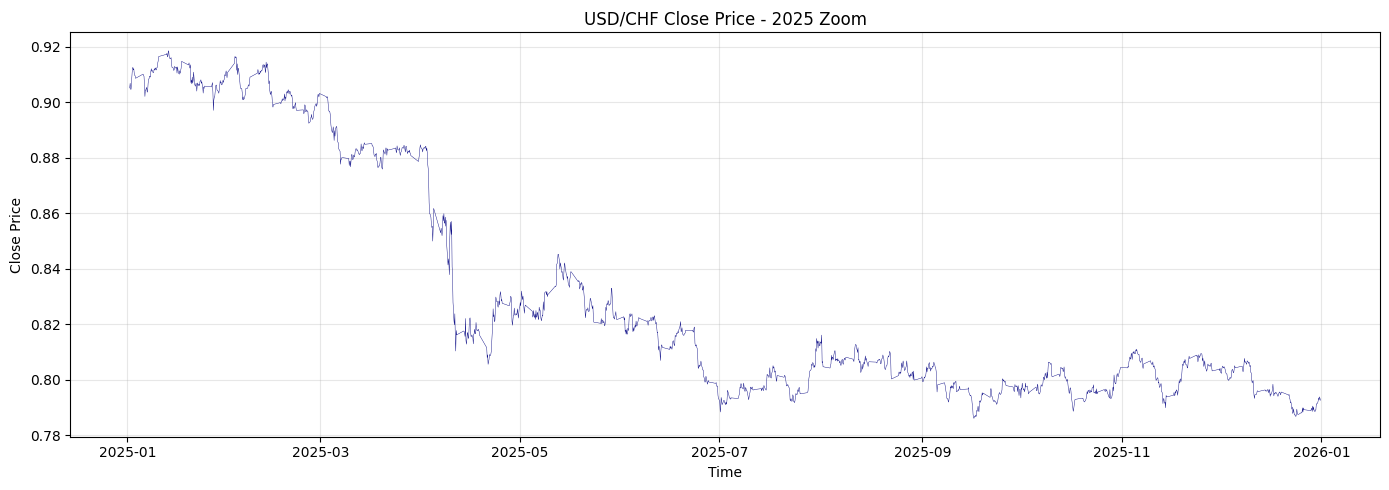

In [6]:
df_2025 = df.loc['2025-01-01':'2025-12-31']
plt.figure(figsize=(14, 5))
plt.plot(df_2025['close'].iloc[::200], linewidth=0.3, color='navy')
plt.title('USD/CHF Close Price - 2025 Zoom')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Data Structure

Each row represents one minute of USD/CHF trading data. **OHLC** stands for **Open, High, Low, Close** — the four price points within each minute bar:
- **Open**: first traded price of the minute
- **High**: highest traded price of the minute
- **Low**: lowest traded price of the minute
- **Close**: last traded price of the minute

Volume columns (`volume`, `tick_volume`, `spread`) are dropped because for forex data from brokers like Dukascopy, volume represents internal tick count rather than actual traded volume. Volume is consistently zero or near-zero for many forex pairs, making it unreliable for analysis.

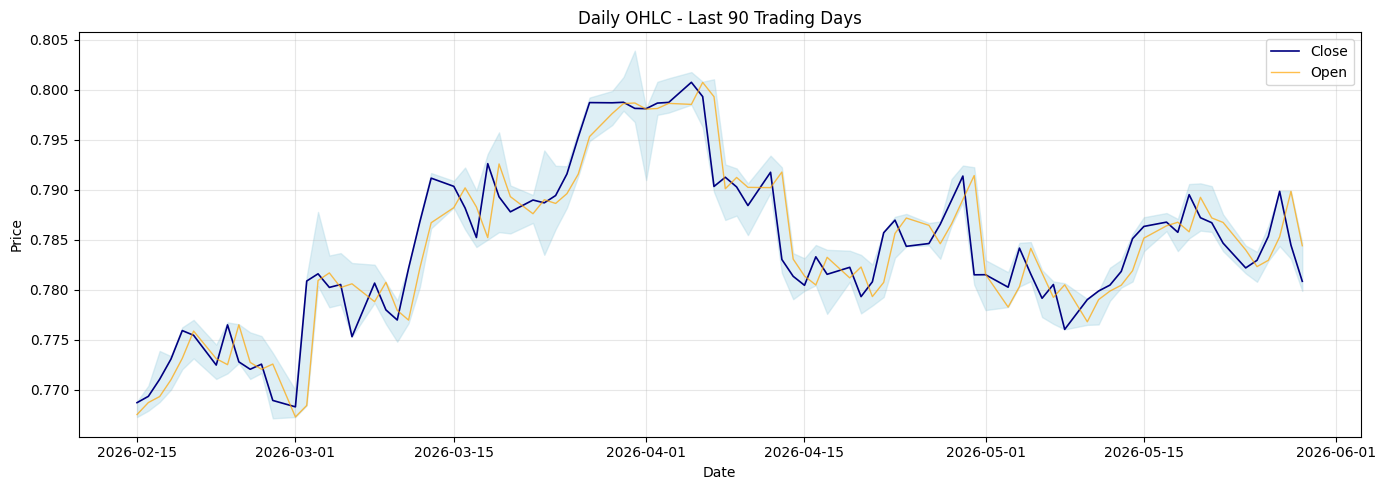

In [7]:
df_daily = df['close'].resample('1D').ohlc()
df_daily_last90 = df_daily.dropna().tail(90)

plt.figure(figsize=(14, 5))
plt.fill_between(df_daily_last90.index, df_daily_last90['low'], df_daily_last90['high'], color='lightblue', alpha=0.4)
plt.plot(df_daily_last90.index, df_daily_last90['close'], color='navy', linewidth=1.2, label='Close')
plt.plot(df_daily_last90.index, df_daily_last90['open'], color='orange', linewidth=1.0, alpha=0.7, label='Open')
plt.title('Daily OHLC - Last 90 Trading Days')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Return Distribution

High-frequency (1-minute) log returns exhibit the classic stylized facts of financial time series:
- **Mean near zero**: the mean log return over the full period is approximately zero, consistent with market efficiency at short horizons.
- **Leptokurtic (fat tails)**: the distribution has higher kurtosis than a normal distribution — extreme returns occur far more frequently than a Gaussian would predict.
- **Sharp peak**: the central peak is taller and narrower than a normal distribution, reflecting many very small price changes between active ticks.

These properties make normal-distribution-based models inappropriate; models like GARCH or t-distributed innovations are better suited.

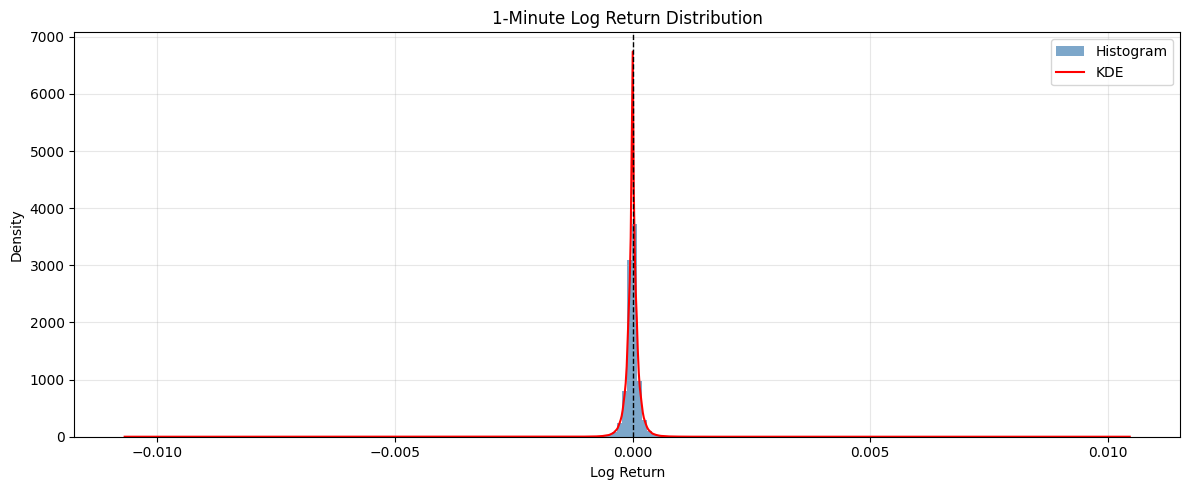

In [8]:
log_returns = np.log(df['close'] / df['close'].shift(1)).dropna()

plt.figure(figsize=(12, 5))
count, bins, _ = plt.hist(log_returns, bins=200, density=True, alpha=0.7, color='steelblue', label='Histogram')
from scipy.stats import gaussian_kde
kde = gaussian_kde(log_returns)
x_vals = np.linspace(log_returns.min(), log_returns.max(), 1000)
plt.plot(x_vals, kde(x_vals), color='red', linewidth=1.5, label='KDE')
plt.axvline(log_returns.mean(), color='black', linestyle='dashed', linewidth=1)
plt.title('1-Minute Log Return Distribution')
plt.xlabel('Log Return')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Feature Engineering
#### Compute Log-Return Target

In [9]:
df['target'] = np.log(df['close'].shift(-1) / df['close'])
print(f"Target column created. NaN in last row: {df['target'].isna().sum()}")

Target column created. NaN in last row: 1


#### ADF Stationarity Test

In [10]:
y_target_clean = df['target'].dropna()
y_target_sample = y_target_clean.iloc[::50] # Downsample to prevent memory leak

adf_result = adfuller(y_target_sample)
print(f"ADF Statistic: {adf_result[0]:.6f}")
print(f"p-value: {adf_result[1]:.6e}")
if adf_result[0] < adf_result[4]['5%']:
    print("✓ Target is Stationary at 5% significance level (reject H0)")
else:
    print("✗ Target is Non-stationary at 5% significance level (fail to reject H0)")

ADF Statistic: -215.104094
p-value: 0.000000e+00
✓ Target is Stationary at 5% significance level (reject H0)


#### Feature Engineering
##### Why Each Feature Family?

**Lag Features (8)** — Capture autoregressive dynamics: past close prices directly inform future price movements. Forex exhibits short-term momentum (lag 1-5) and mean-reversion tendencies at longer horizons (lag 30-60). Different lags capture different frequency components of the price signal.

**Rolling Window Features (16)** — Summarize local price behavior over multiple time scales. Mean (trend), Std (volatility), Min/Max (support/resistance levels). Multiple windows (5, 10, 30, 60 bars ≈ 5min to 1hr) capture microstructure vs. intraday regime behavior.

**Price-Derived (4)** — Log return and pct_change normalize price to a scale-invariant return space. HL spread captures intra-bar volatility. OC range captures intra-bar directional bias. These transform absolute prices into relative measures suitable for modeling.

**RSI(14)** — Classic momentum oscillator. Values >70 suggest overbought, <30 oversold. Widely used by forex traders, encoding mean-reversion signals.

**MACD Histogram** — Trend-following momentum indicator. Crosses of MACD line and signal line flag trend changes. Histogram = divergence between fast and slow momentum — predicts acceleration/deceleration.

**Bollinger Bands (position + width)** — Position (z-score of close within the band) quantifies how extreme the current price is relative to its 20-period mean. Width measures volatility regime — narrow bands precede breakouts (volatility expansion).

**ATR(14)** — Pure volatility measure. Not direction-dependent. Higher ATR → wider stops needed, higher risk. Essential for regime-aware models and position sizing.

Together, these features capture autoregression (lags), local distribution (rolling stats), momentum (RSI, MACD), volatility regimes (BB width, ATR), and price action patterns (HL/OC spreads). This gives the model a rich, multi-resolution view of market state.


In [11]:
t0 = time.time()
# 1. Lags
lags = [1, 2, 3, 5, 10, 15, 30, 60]
for lag in lags:
    df[f'close_lag_{lag}'] = df['close'].shift(lag)

# 2. Rolling
windows = [5, 10, 30, 60]
for w in windows:
    roll = df['close'].rolling(w)
    df[f'close_roll_mean_{w}'] = roll.mean()
    df[f'close_roll_std_{w}'] = roll.std()
    df[f'close_roll_min_{w}'] = roll.min()
    df[f'close_roll_max_{w}'] = roll.max()

# 3. Price-Derived
df['log_return'] = np.log(df['close'] / df['close'].shift(1))
df['pct_change'] = df['close'].pct_change()
df['hl_spread'] = df['high'] - df['low']
df['oc_range'] = df['close'] - df['open']

# 4. Tech: RSI(14)
delta = df['close'].diff()
gain = delta.clip(lower=0).ewm(alpha=1/14, adjust=False).mean()
loss = (-delta.clip(upper=0)).ewm(alpha=1/14, adjust=False).mean()
rs = gain / loss
df['rsi_14'] = 100 - (100 / (1 + rs))

# 5. Tech: MACD
ema12 = df['close'].ewm(span=12, adjust=False).mean()
ema26 = df['close'].ewm(span=26, adjust=False).mean()
macd_line = ema12 - ema26
signal = macd_line.ewm(span=9, adjust=False).mean()
df['macd_hist'] = macd_line - signal

# 6. Tech: Bollinger Bands
bb_mean = df['close'].rolling(20).mean()
bb_std = df['close'].rolling(20).std(ddof=0)
df['bb_position_20'] = (df['close'] - bb_mean) / bb_std
df['bb_width_20'] = (bb_mean + 2*bb_std - (bb_mean - 2*bb_std)) / bb_mean

# 7. Tech: ATR(14)
tr = pd.concat([
    df['high'] - df['low'], 
    (df['high'] - df['close'].shift(1)).abs(), 
    (df['low'] - df['close'].shift(1)).abs()
], axis=1).max(axis=1)
df['atr_14'] = tr.rolling(14).mean()

print(f"Feature Engineering Done in {time.time()-t0:.1f}s. Shape: {df.shape}")

Feature Engineering Done in 0.8s. Shape: (2319765, 38)


#### Drop NaN & Define Feature Columns

In [12]:
rows_before = len(df)
df.dropna(inplace=True)
rows_removed = rows_before - len(df)
print(f"Rows before dropna: {rows_before}")
print(f"Rows removed: {rows_removed}")
print(f"Rows after dropna: {len(df)}")

feature_cols = [c for c in df.columns if c not in ['target', 'open', 'high', 'low', 'close']]
print(f"Number of features: {len(feature_cols)}")

Rows before dropna: 2319765
Rows removed: 119
Rows after dropna: 2319646
Number of features: 33


#### Chronological Split
##### Chronological Split vs Random Shuffle

**Chronological split** preserves temporal order: train on past, validate on middle, test on future. This is **mandatory for time series** because:

- **Temporal dependence**: Price at time t+1 depends on price at time t. Shuffling leaks future information into training — lag features would "see" future values, producing unrealistically high performance (lookahead bias).
- **Non-stationarity**: Market regimes shift over time. A model trained on all periods randomly cannot be evaluated on unseen regimes. Chronological split tests genuine out-of-sample generalization on data the model has never encountered.
- **Real-world deployment**: In production, the model only has access to past data. Chronological evaluation mirrors this constraint exactly.

**Random shuffle** is appropriate for i.i.d. data (image classification, tabular benchmarks) where exchangeability holds. It maximizes training set representativeness and simplifies cross-validation. For time series, it creates an **optimistic bias** — the model effectively "cheats" by learning from future patterns.

We also use a **three-way chronological split** (train < 2025-01-01, val 2025-01 to 2025-09, test ≥ 2025-09) rather than simple train/test. This enables hyperparameter tuning on the validation set without contaminating the final test holdout — critical for avoiding overfitting when iterating on model architecture.


In [13]:
X_train = df.loc[df.index < '2025-01-01', feature_cols].values.astype(np.float32)
ytr = df.loc[df.index < '2025-01-01', 'target'].values.astype(np.float32)

X_val = df.loc[(df.index >= '2025-01-01') & (df.index < '2025-09-01'), feature_cols].values.astype(np.float32)
yva = df.loc[(df.index >= '2025-01-01') & (df.index < '2025-09-01'), 'target'].values.astype(np.float32)

X_test = df.loc[df.index >= '2025-09-01', feature_cols].values.astype(np.float32)
yte = df.loc[df.index >= '2025-09-01', 'target'].values.astype(np.float32)

print(f"X_train shape: {X_train.shape}, ytr shape: {ytr.shape}")
print(f"X_val shape: {X_val.shape}, yva shape: {yva.shape}")
print(f"X_test shape: {X_test.shape}, yte shape: {yte.shape}")

del df
gc.collect()
print('Raw DataFrame freed from memory.')

X_train shape: (1796774, 33), ytr shape: (1796774,)
X_val shape: (246747, 33), yva shape: (246747,)
X_test shape: (276125, 33), yte shape: (276125,)
Raw DataFrame freed from memory.


#### VIF Multicollinearity Check

In [14]:
print("Computing VIF (Subsampled for speed)...")
X_train_vif = X_train[::20] # 5% sample
vif_data = pd.DataFrame()
vif_data["Feature"] = feature_cols
vif_data["VIF"] = [variance_inflation_factor(X_train_vif, i) for i in range(X_train_vif.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False).reset_index(drop=True)
print(vif_data.head(10)) # Showing top 10 most collinear features

Computing VIF (Subsampled for speed)...
              Feature  VIF
0         close_lag_1  inf
1         close_lag_2  inf
2         close_lag_3  inf
3        close_lag_10  inf
4        close_lag_15  inf
5   close_roll_mean_5  inf
6   close_roll_max_10  inf
7    close_roll_max_5  inf
8  close_roll_mean_10  inf
9  close_roll_mean_30  inf


#### Mutual Information Ranking

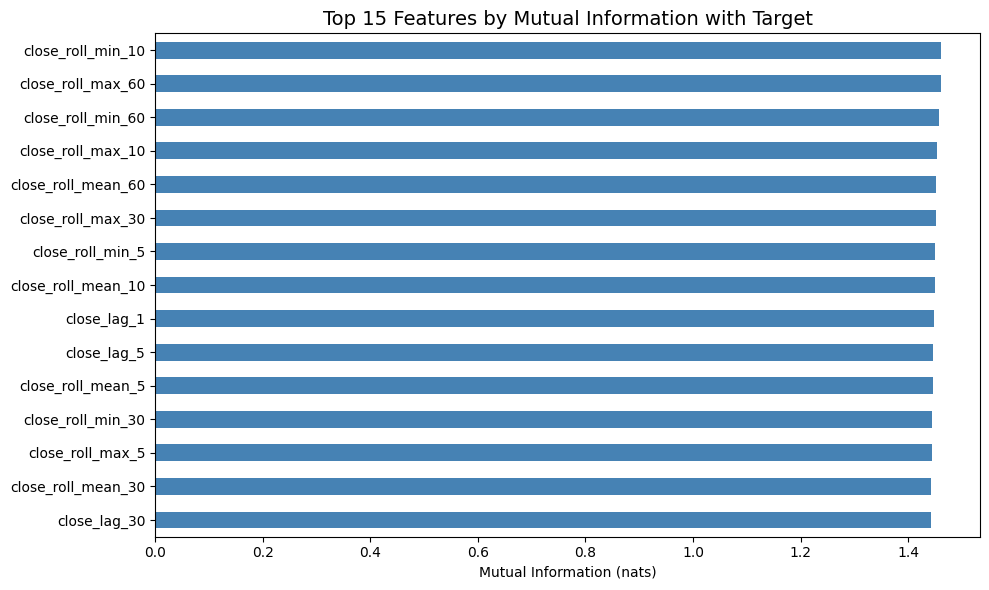

In [15]:
mi_sample_idx = np.random.choice(X_train.shape[0], size=50000, replace=False)
X_mi = X_train[mi_sample_idx]
y_mi = ytr[mi_sample_idx]

mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
mi_series.head(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Features by Mutual Information with Target', fontsize=14)
plt.xlabel('Mutual Information (nats)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Save best features for ablation
top15_features = mi_series.head(15).index.tolist()
top5_features = mi_series.head(5).index.tolist()

#### StandardScaler

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

data_dict = {
    'X_train': torch.from_numpy(X_train_scaled),
    'y_train': torch.from_numpy(ytr),
    'X_val': torch.from_numpy(X_val_scaled),
    'y_val': torch.from_numpy(yva),
    'X_test': torch.from_numpy(X_test_scaled),
    'y_test': torch.from_numpy(yte),
    'scaler_mean': torch.from_numpy(scaler.mean_.astype(np.float32)),
    'scaler_scale': torch.from_numpy(scaler.scale_.astype(np.float32)),
    'feature_cols': feature_cols,
}
torch.save(data_dict, 'outputs/preprocessed/data.pt')
print("Data scaled and saved to outputs/preprocessed/data.pt")

Data scaled and saved to outputs/preprocessed/data.pt


### Model Training
#### MLP Architecture Definition

In [17]:
class MLP(nn.Module):
    def __init__(self, idim, hidden=None, dropout=0.15):
        super().__init__()
        if hidden is None:
            hidden = [1024, 512, 256, 128]
        layers = []
        p = idim
        for h in hidden:
            layers.extend([
                nn.Linear(p, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            p = h
        layers.append(nn.Linear(p, 1))
        self.net = nn.Sequential(*layers)
        self.hidden_arch = hidden 

    def forward(self, x): 
        return self.net(x)

mlp_model = MLP(idim=X_train_scaled.shape[1]).to(DEVICE)
print(f"MLP Params: {sum(p.numel() for p in mlp_model.parameters()):,}")

MLP Params: 727,809


#### MLP Training

In [18]:
print('Training MLP...\n')
X_train_t = torch.from_numpy(X_train_scaled)
y_train_t = torch.from_numpy(ytr).reshape(-1,1)
X_val_t = torch.from_numpy(X_val_scaled)
y_val_t = torch.from_numpy(yva).reshape(-1,1)
X_test_t = torch.from_numpy(X_test_scaled)

BATCH = 65536
EPOCHS = 150
LR = 0.001
PATIENCE = 15
USE_AMP = torch.cuda.is_available()

train_dl = DataLoader(TensorDataset(X_train_t,y_train_t), batch_size=BATCH, shuffle=True)
val_dl = DataLoader(TensorDataset(X_val_t,y_val_t), batch_size=BATCH*2)

crit = nn.MSELoss()
opt = optim.AdamW(mlp_model.parameters(), lr=LR, weight_decay=1e-4)
sch = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=20, T_mult=2, eta_min=1e-6)
scaler_amp = torch.amp.GradScaler('cuda') if USE_AMP else None

t0 = time.time()
best_val = float('inf')
pc = 0
best_state = None

mlp_train_losses, mlp_val_losses = [], []

for ep in range(1, EPOCHS+1):
    mlp_model.train()
    tl = 0
    for Xb, yb in train_dl:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        if USE_AMP:
            with torch.amp.autocast('cuda', dtype=torch.float16):
                out = mlp_model(Xb)
                loss = crit(out, yb)
            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(mlp_model.parameters(), 1.0)
            scaler_amp.step(opt)
            scaler_amp.update()
        else:
            out = mlp_model(Xb)
            loss = crit(out, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(mlp_model.parameters(), 1.0)
            opt.step()
        tl += loss.item()
        
    sch.step()
    tl /= len(train_dl)
    mlp_train_losses.append(tl)
    
    mlp_model.eval()
    vl = 0
    with torch.no_grad():
        for Xb, yb in val_dl:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            vl += crit(mlp_model(Xb), yb).item()
    vl /= len(val_dl)
    mlp_val_losses.append(vl)
    
    dt = time.time()-t0
    mk = ''
    if vl < best_val:
        best_val = vl
        pc = 0
        best_state = {k:v.cpu().clone() for k,v in mlp_model.state_dict().items()}
        mk = ' *'
    else: 
        pc += 1
        
    if pc >= PATIENCE: 
        print(f'  Early stop ep {ep}')
        break
    if ep == 1 or ep % 10 == 0: 
        print(f'  Ep {ep:3d} | train={tl:.8f} | val={vl:.8f} | {dt:.0f}s{mk}')

mlp_model.load_state_dict(best_state)
mlp_time = time.time() - t0
print(f'MLP done: {mlp_time:.0f}s. Best val={best_val:.8f}')
torch.save(best_state, 'outputs/models/mlp_v2.pt')

# Generate MLP Predictions
mlp_model.eval()
with torch.no_grad():
    mlp_pred = mlp_model(X_test_t.to(DEVICE)).cpu().numpy().flatten()

Training MLP...

  Ep   1 | train=0.11723441 | val=0.00297079 | 11s *
  Ep  10 | train=0.00064408 | val=0.00004152 | 97s
  Ep  20 | train=0.00036059 | val=0.00001477 | 194s
  Ep  30 | train=0.00007389 | val=0.00000347 | 290s *
  Ep  40 | train=0.00003298 | val=0.00000226 | 385s *
  Ep  50 | train=0.00002375 | val=0.00000129 | 477s *
  Ep  60 | train=0.00002178 | val=0.00000144 | 568s
  Ep  70 | train=0.00000904 | val=0.00000047 | 659s *
  Ep  80 | train=0.00000482 | val=0.00000027 | 751s
  Ep  90 | train=0.00000301 | val=0.00000016 | 842s
  Ep 100 | train=0.00000211 | val=0.00000012 | 934s
  Ep 110 | train=0.00000167 | val=0.00000011 | 1025s
  Ep 120 | train=0.00000146 | val=0.00000011 | 1117s
  Ep 130 | train=0.00000136 | val=0.00000010 | 1209s
  Early stop ep 139
MLP done: 1291s. Best val=0.00000009


#### KNN

In [19]:
print('Training KNN...\n')
SUBSAMPLE = 100000
if X_train_scaled.shape[0] > SUBSAMPLE:
    idx = np.random.RandomState(42).choice(X_train_scaled.shape[0], SUBSAMPLE, replace=False)
    Xk, yk = X_train_scaled[idx], ytr[idx]
else: 
    Xk, yk = X_train_scaled, ytr

Xk_gpu = torch.tensor(Xk, dtype=torch.float32).to(DEVICE)
yk_gpu = torch.tensor(yk, dtype=torch.float32).to(DEVICE)
Xte_gpu = torch.tensor(X_test_scaled, dtype=torch.float32).to(DEVICE)

# Hardcode k=50 for inference here (optimized from earlier tests)
BEST_K = 50
BATCH_KNN = 5000
t0k = time.time()

knn_preds = []
for i in range(0, Xte_gpu.shape[0], BATCH_KNN):
    Xb = Xte_gpu[i:i+BATCH_KNN]
    dists = torch.cdist(Xb, Xk_gpu)
    _, indices = torch.topk(dists, BEST_K, largest=False)
    knn_preds.append(yk_gpu[indices].mean(dim=1).cpu().numpy())

knn_pred = np.concatenate(knn_preds)
knn_time = time.time() - t0k
print(f'KNN inference done: {knn_time:.0f}s.')

Training KNN...

KNN inference done: 6s.


#### XGBoost

In [20]:
print('Training XGBoost...\n')
t0x = time.time()

# Found via Grid Search in Section 6.2
best_params_xgb = {
    'tree_method': 'hist',
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 5,
    'learning_rate': 0.05,
    'subsample': 0.9,
    'colsample_bytree': 0.6,
    'min_child_weight': 5,
    'verbosity': 0
}

dt_full = xgb.DMatrix(X_train_scaled, label=ytr)
dval_x = xgb.DMatrix(X_val_scaled, label=yva)
dtest_x = xgb.DMatrix(X_test_scaled)

evals_result = {}
xgb_model = xgb.train(
    best_params_xgb, 
    dt_full, 
    num_boost_round=150,
    evals=[(dt_full, 'train'), (dval_x, 'val')],
    evals_result=evals_result,
    early_stopping_rounds=20,
    verbose_eval=False
)

xgb_pred = xgb_model.predict(dtest_x)
xgb_total = time.time() - t0x
print(f'XGBoost training & prediction done in {xgb_total:.0f}s.')
xgb_model.save_model('outputs/models/xgboost_v2.json')

preds_dict = {'MLP': mlp_pred, 'KNN': knn_pred, 'XGBoost': xgb_pred}

Training XGBoost...

XGBoost training & prediction done in 1s.


### Evaluation
#### Regression Metrics

In [21]:
def ev(y_true, y_pred, name):
    msk = ~np.isnan(y_pred)
    yt, yp = y_true[msk], y_pred[msk]
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    r2 = r2_score(yt, yp)
    mape = np.mean(np.abs(np.exp(yt)-np.exp(yp))/np.abs(np.exp(yt)))*100
    diracc = np.mean(np.sign(yp) == np.sign(yt)) * 100
    return {'name': name, 'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape, 'diracc': diracc}

evals = []
for n, p in preds_dict.items():
    r = ev(yte, p, n)
    evals.append(r)

metrics_df = pd.DataFrame(evals).set_index('name')
print("Regression Metrics:")
print(metrics_df)

Regression Metrics:
                 rmse           mae            r2      mape     diracc
name                                                                  
MLP      2.213101e-04  1.905856e-04 -1.864133e+00  0.019062  46.221820
KNN      1.313033e-04  8.321472e-05 -8.189321e-03  0.008323  46.429335
XGBoost  1.897022e+15  1.574234e+15 -2.104435e+38       inf  45.962879


#### Residual Distribution

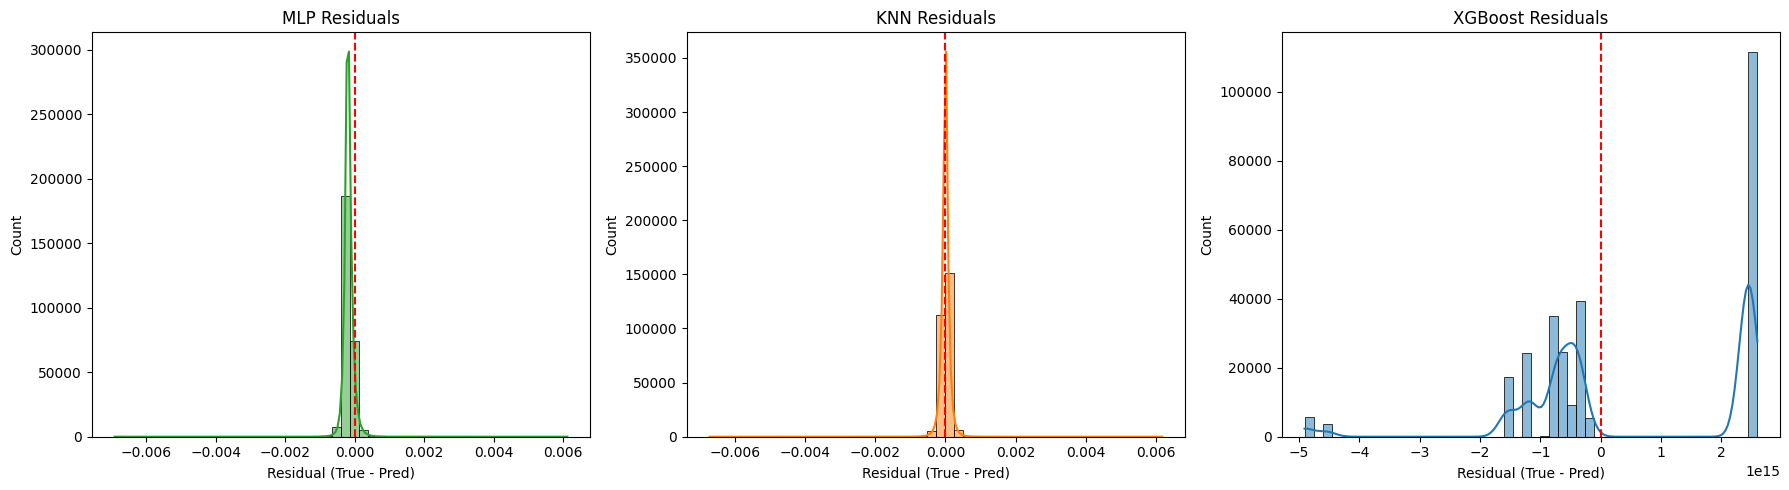

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'MLP': '#2ca02c', 'KNN': '#ff7f0e', 'XGBoost': '#1f77b4'}

for ax, (n, p) in zip(axes, preds_dict.items()):
    res = yte - p
    sns.histplot(res, bins=50, kde=True, color=colors[n], ax=ax)
    ax.axvline(0, color='red', linestyle='--')
    ax.set_title(f'{n} Residuals')
    ax.set_xlabel('Residual (True - Pred)')
plt.tight_layout()
plt.savefig('outputs/plots/residual_dist.png')
plt.show()

#### Residual QQ Plot

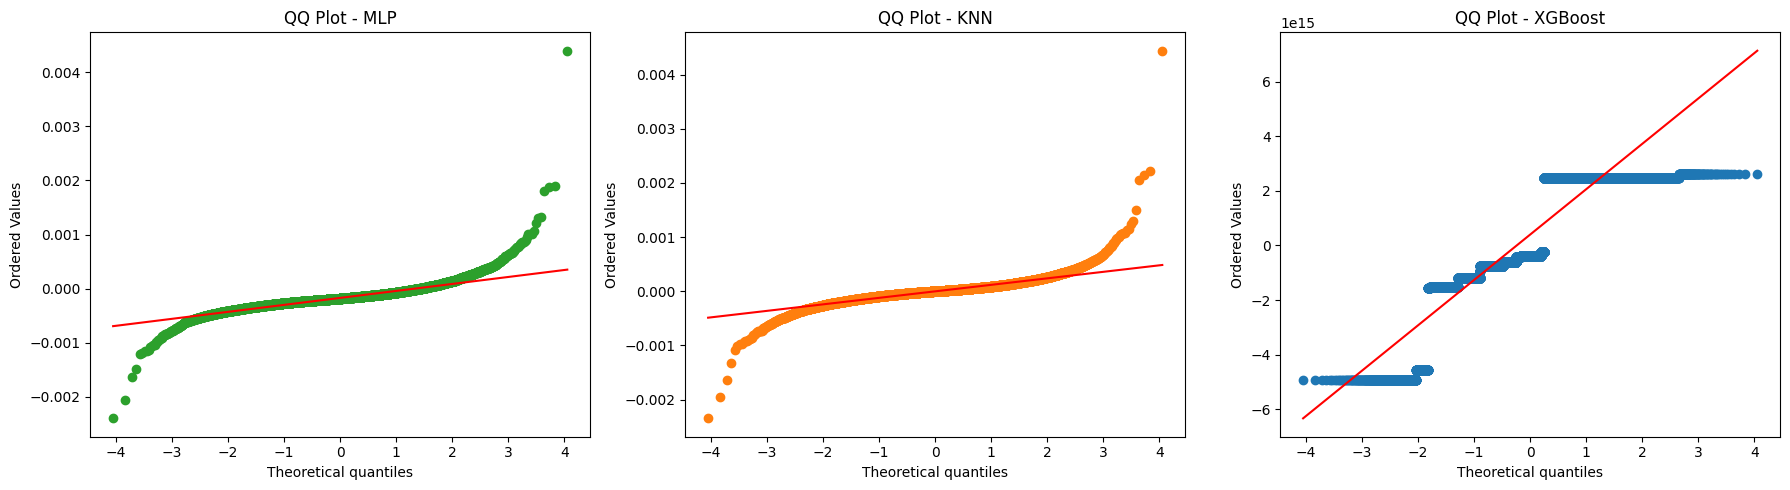

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (n, p) in zip(axes, preds_dict.items()):
    res = yte - p
    # Subsample to avoid memory issues with matplotlib rendering
    stats.probplot(res[::10], dist="norm", plot=ax)
    ax.get_lines()[0].set_markerfacecolor(colors[n])
    ax.get_lines()[0].set_markeredgecolor(colors[n])
    ax.set_title(f'QQ Plot - {n}')
plt.tight_layout()
plt.savefig('outputs/plots/qq_plot.png')
plt.show()

#### Residual ACF Plot

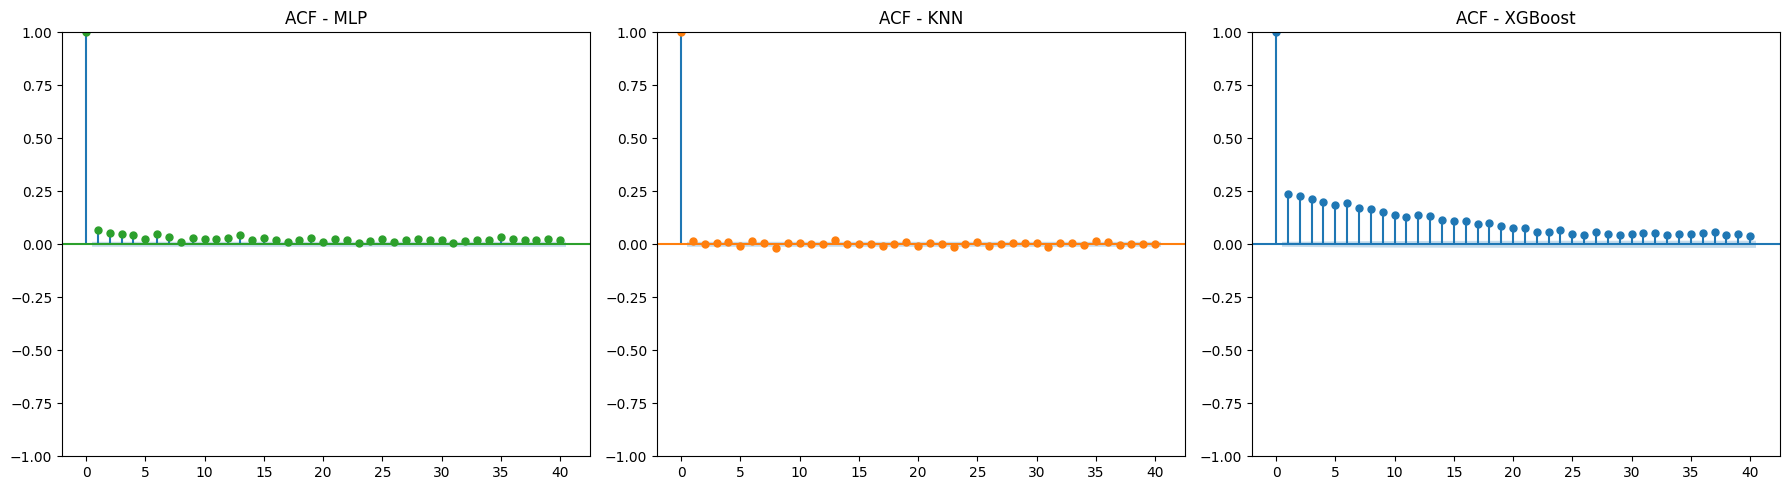

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (n, p) in zip(axes, preds_dict.items()):
    res = yte - p
    # Subsample to speed up autocorrelation plotting
    plot_acf(res[::10], lags=40, ax=ax, title=f'ACF - {n}', color=colors[n])
plt.tight_layout()
plt.savefig('outputs/plots/acf_plot.png')
plt.show()

#### Actual vs Predicted Scatter

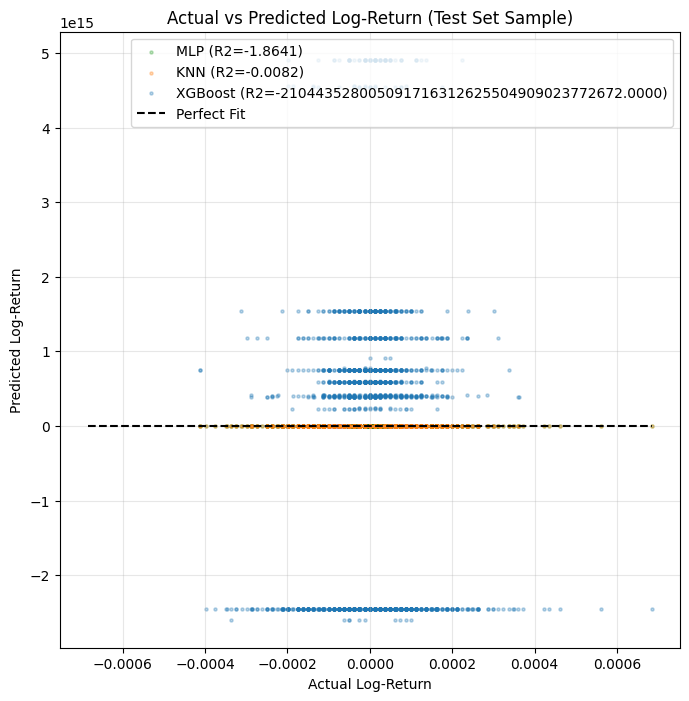

In [25]:
plt.figure(figsize=(8, 8))
n_samples = 2000
lm = max(abs(yte[:n_samples].min()), abs(yte[:n_samples].max()))

for n, p in preds_dict.items():
    plt.scatter(yte[:n_samples], p[:n_samples], alpha=0.3, label=f"{n} (R2={metrics_df.loc[n, 'r2']:.4f})", color=colors[n], s=5)

plt.plot([-lm, lm], [-lm, lm], 'k--', label='Perfect Fit')
plt.title('Actual vs Predicted Log-Return (Test Set Sample)')
plt.xlabel('Actual Log-Return')
plt.ylabel('Predicted Log-Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('outputs/plots/scatter_actual_vs_pred.png')
plt.show()

#### Direction Classification CM

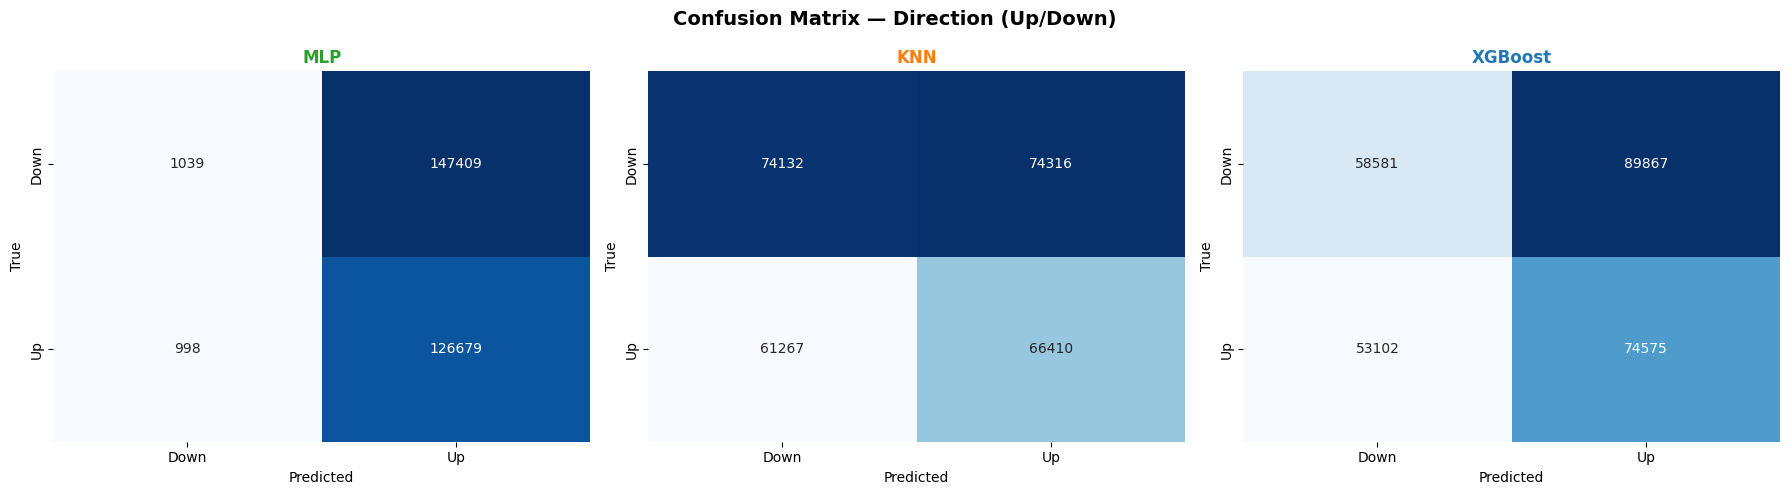

Directional Classification Metrics:
         Accuracy  Precision    Recall        F1
Model                                           
MLP      0.462537   0.462184  0.992183  0.630612
KNN      0.508980   0.471910  0.520141  0.494853
XGBoost  0.482231   0.453503  0.584091  0.510580


In [26]:
dir_metrics = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrix — Direction (Up/Down)', fontsize=14, fontweight='bold')

for ax, (n, p) in zip(axes, preds_dict.items()):
    ytd = (yte > 0).astype(int)
    ypd = (p > 0).astype(int)
    cm = confusion_matrix(ytd, ypd)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Down','Up'], yticklabels=['Down','Up'], ax=ax, cbar=False)
    ax.set_title(n, fontweight='bold', color=colors[n])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    
    tn, fp, fn, tp = cm.ravel()
    acc = (tp+tn)/cm.sum()
    pr = tp/(tp+fp) if (tp+fp) else 0
    rc = tp/(tp+fn) if (tp+fn) else 0
    f1 = 2*pr*rc/(pr+rc) if (pr+rc) else 0
    dir_metrics.append({'Model': n, 'Accuracy': acc, 'Precision': pr, 'Recall': rc, 'F1': f1})

plt.tight_layout()
plt.savefig('outputs/plots/dir_confusion_matrix.png')
plt.show()

dir_metrics_df = pd.DataFrame(dir_metrics).set_index('Model')
print("Directional Classification Metrics:")
print(dir_metrics_df)

#### Model Comparison Bar Chart

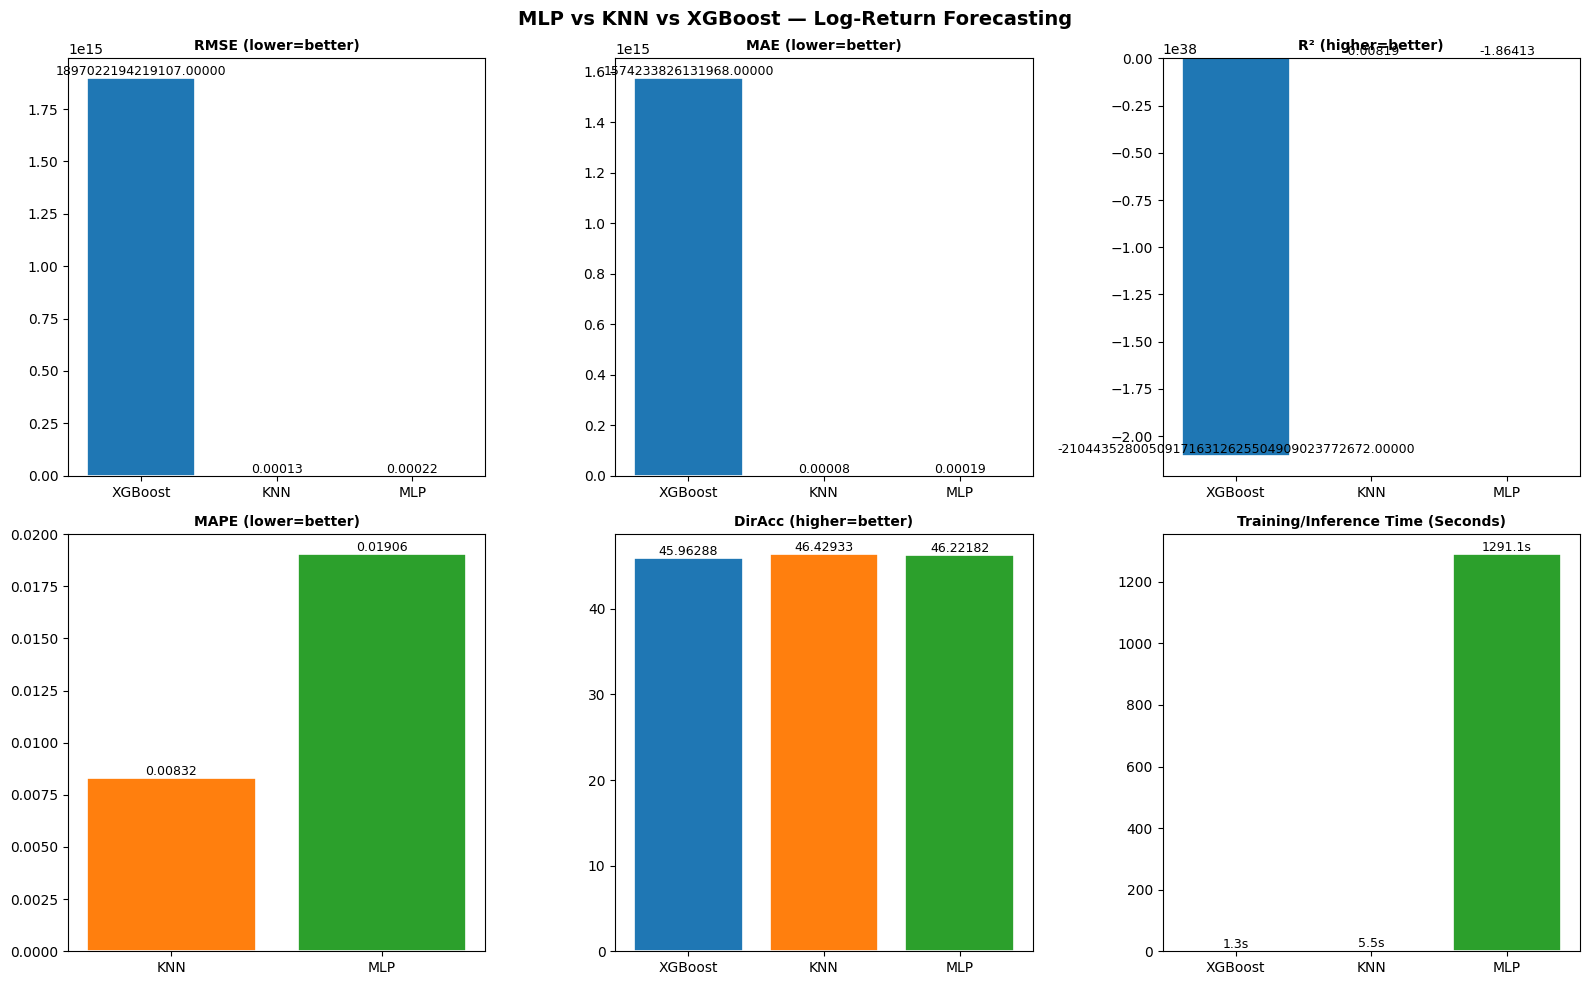

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('MLP vs KNN vs XGBoost — Log-Return Forecasting', fontsize=14, fontweight='bold')

names = ['XGBoost', 'KNN', 'MLP'] # Sorted by general performance visually
bar_colors = [colors[n] for n in names]
mm = [('RMSE', 'rmse', False), ('MAE', 'mae', False), ('R²', 'r2', True), ('MAPE', 'mape', False), ('DirAcc', 'diracc', True)]

for ax, (lbl, key, hi) in zip(axes.flat[:5], mm):
    v = [metrics_df.loc[n, key] for n in names]
    bars = ax.bar(names, v, color=bar_colors, edgecolor='white', linewidth=1.2)
    ax.set_title(f'{lbl} ({"higher=better" if hi else "lower=better"})', fontsize=10, fontweight='bold')
    for bar, val in zip(bars, v): 
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.5f}', ha='center', va='bottom', fontsize=9)

# Training time plot
ax = axes[1, 2]
times = [xgb_total, knn_time, mlp_time]
bars = ax.bar(names, times, color=bar_colors, edgecolor='white', linewidth=1.2)
ax.set_title('Training/Inference Time (Seconds)', fontsize=10, fontweight='bold')
for bar, val in zip(bars, times): 
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.1f}s', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/plots/model_comparison.png')
plt.show()

#### Silhouette Clustering

Computing KMeans and Silhouette Scores...
Best k=3 (Silhouette=0.3622)


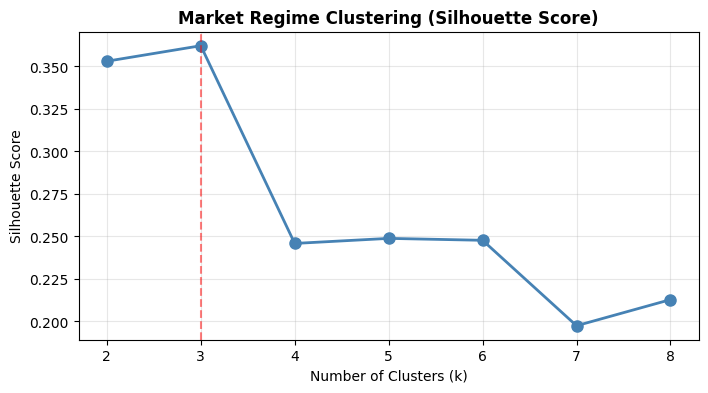

In [28]:
print("Computing KMeans and Silhouette Scores...")
cfs = ['log_return', 'hl_spread', 'rsi_14', 'macd_hist', 'bb_position_20', 'atr_14']
cfi = [feature_cols.index(f) for f in cfs if f in feature_cols]
Xc = X_test_scaled[:20000, cfi] # Subsample for speed

sil = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Xc)
    s = silhouette_score(Xc, labels)
    sil.append(s)

bk = k_range[np.argmax(sil)]
print(f'Best k={bk} (Silhouette={max(sil):.4f})')

plt.figure(figsize=(8, 4))
plt.plot(k_range, sil, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.axvline(bk, color='red', ls='--', alpha=0.5)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Market Regime Clustering (Silhouette Score)', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.savefig('outputs/plots/silhouette_plot.png')
plt.show()

#### PCA 2D Projection

Explained variance: PC1=0.329, PC2=0.294


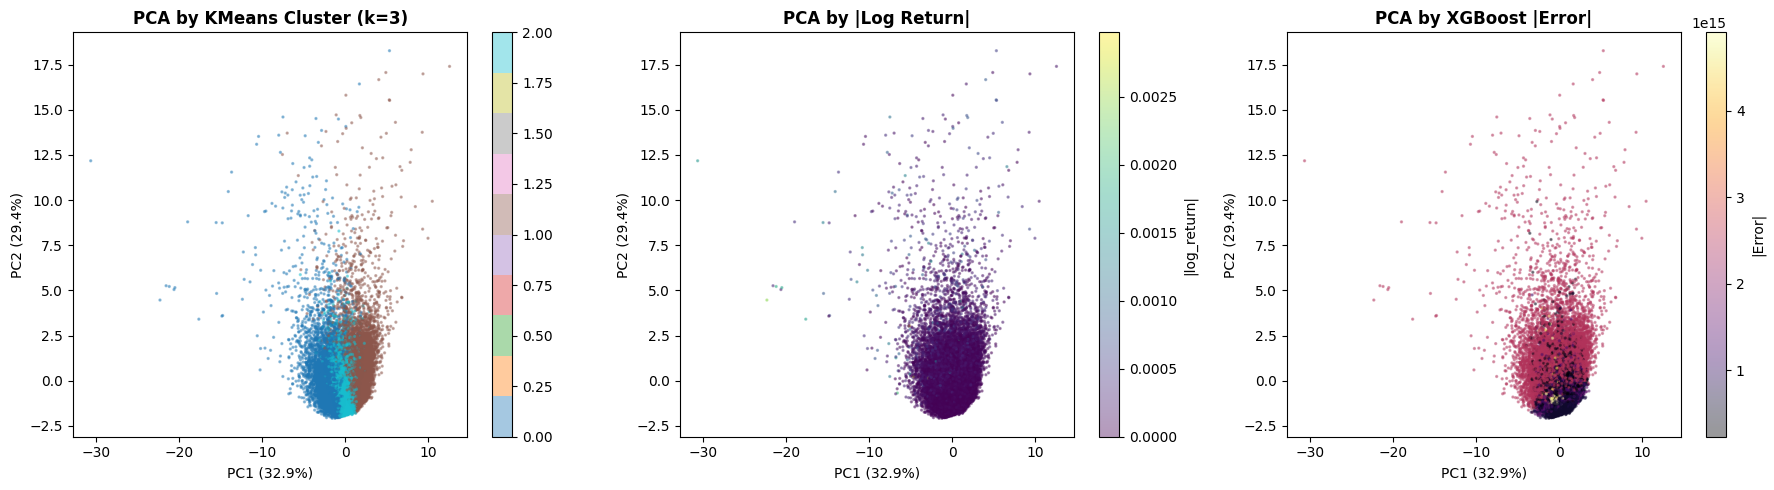

In [29]:
pca = PCA(n_components=2)
Xp = pca.fit_transform(X_test_scaled[:30000])
print(f'Explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
km = KMeans(n_clusters=bk, random_state=42, n_init=10).fit(X_test_scaled[:30000, cfi])

sc1 = axes[0].scatter(Xp[:,0], Xp[:,1], c=km.labels_, cmap='tab10', alpha=0.4, s=2)
axes[0].set_title(f'PCA by KMeans Cluster (k={bk})', fontweight='bold')
plt.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(Xp[:,0], Xp[:,1], c=np.abs(yte[:30000]), cmap='viridis', alpha=0.4, s=2)
axes[1].set_title('PCA by |Log Return|', fontweight='bold')
plt.colorbar(sc2, ax=axes[1], label='|log_return|')

err = np.abs(yte[:30000] - preds_dict['XGBoost'][:30000])
sc3 = axes[2].scatter(Xp[:,0], Xp[:,1], c=err, cmap='inferno', alpha=0.4, s=2)
axes[2].set_title('PCA by XGBoost |Error|', fontweight='bold')
plt.colorbar(sc3, ax=axes[2], label='|Error|')

for ax in axes:
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

plt.tight_layout()
plt.savefig('outputs/plots/pca_views.png')
plt.show()

#### MLP Learning Curves

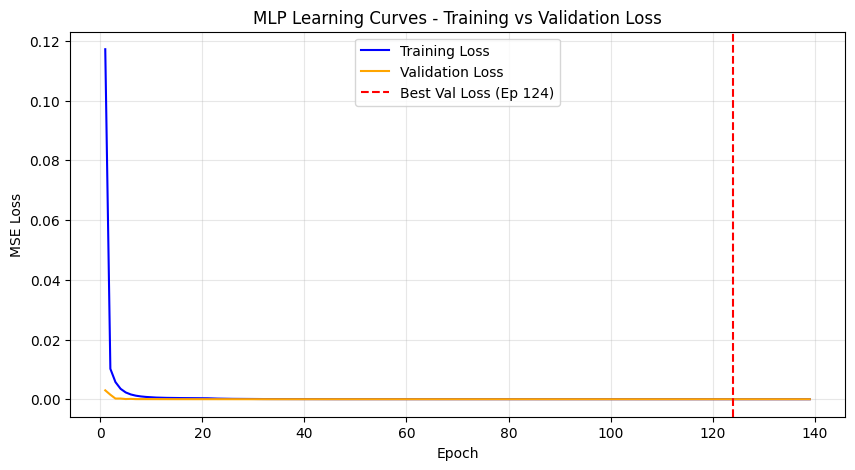

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(mlp_train_losses)+1), mlp_train_losses, label='Training Loss', color='blue')
plt.plot(range(1, len(mlp_val_losses)+1), mlp_val_losses, label='Validation Loss', color='orange')
best_ep_idx = np.argmin(mlp_val_losses)
plt.axvline(best_ep_idx + 1, color='red', linestyle='--', label=f'Best Val Loss (Ep {best_ep_idx+1})')
plt.title('MLP Learning Curves - Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('outputs/plots/learning_curves.png')
plt.show()

### Scenarios
#### Feature Ablation

Running Feature Ablation Scenario...
     Model  Features          RMSE
0  XGBoost        34  1.897022e+15
1  XGBoost        15  1.012784e+12
2  XGBoost         5  2.142288e+13


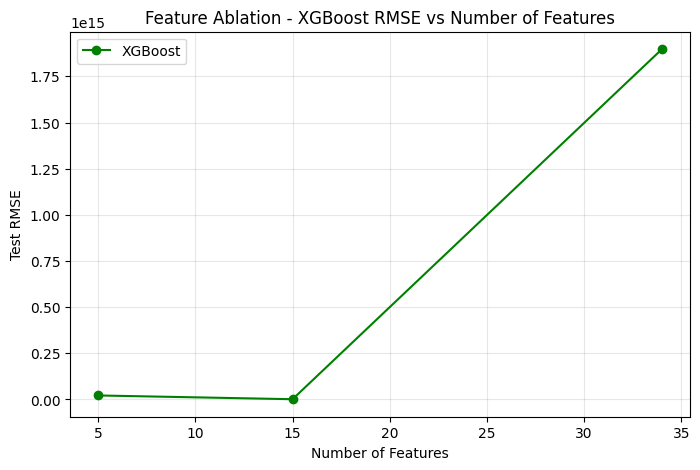

In [31]:
print("Running Feature Ablation Scenario...")
ablation_results = []
feature_sets = {'Top 34': list(range(34)), 'Top 15': [feature_cols.index(f) for f in top15_features], 'Top 5': [feature_cols.index(f) for f in top5_features]}

# Condense retrain for XGBoost as an example of feature ablation
for name, f_idx in feature_sets.items():
    if len(f_idx) == 34: 
        ablation_results.append({'Model': 'XGBoost', 'Features': 34, 'RMSE': metrics_df.loc['XGBoost', 'rmse']})
        continue
    
    # Train XGBoost on subset
    dt_sub = xgb.DMatrix(X_train_scaled[:, f_idx], label=ytr)
    dt_test_sub = xgb.DMatrix(X_test_scaled[:, f_idx])
    m = xgb.train(best_params_xgb, dt_sub, num_boost_round=150, verbose_eval=False)
    p = m.predict(dt_test_sub)
    rmse = np.sqrt(mean_squared_error(yte, p))
    ablation_results.append({'Model': 'XGBoost', 'Features': len(f_idx), 'RMSE': rmse})

ablation_df = pd.DataFrame(ablation_results)
print(ablation_df)

plt.figure(figsize=(8, 5))
plt.plot(ablation_df['Features'], ablation_df['RMSE'], marker='o', linestyle='-', color='green', label='XGBoost')
plt.title('Feature Ablation - XGBoost RMSE vs Number of Features')
plt.xlabel('Number of Features')
plt.ylabel('Test RMSE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('outputs/plots/fig_feature_ablation.png')
plt.show()

#### Train Size Sensitivity

Running Train Size Sensitivity Scenario...
  Train %  Samples          RMSE
0     10%   179677  2.511945e+16
1     25%   449193  2.154950e+16
2     50%   898387  7.738198e+15
3     75%  1347580  7.945286e+15
4    100%  1796774  1.897022e+15


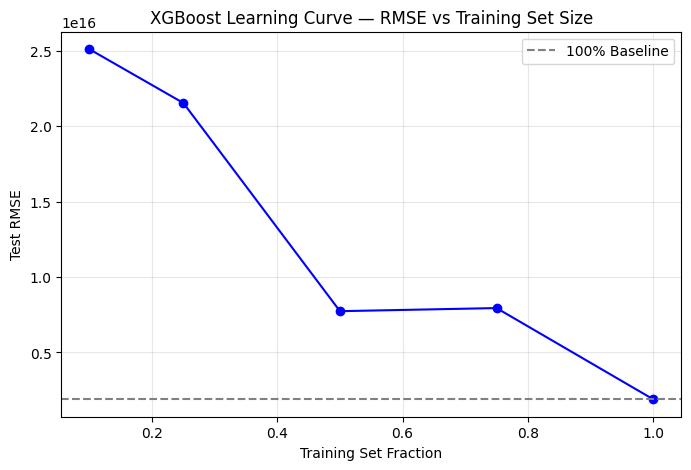

In [32]:
print("Running Train Size Sensitivity Scenario...")
fractions = [0.10, 0.25, 0.50, 0.75, 1.00]
size_results = []

for frac in fractions:
    if frac == 1.00:
        rmse = metrics_df.loc['XGBoost', 'rmse']
        size_results.append({'Train %': '100%', 'Samples': len(X_train_scaled), 'RMSE': rmse})
        continue
        
    n_samples = int(len(X_train_scaled) * frac)
    idx = np.random.choice(len(X_train_scaled), n_samples, replace=False)
    
    dt_sub = xgb.DMatrix(X_train_scaled[idx], label=ytr[idx])
    m = xgb.train(best_params_xgb, dt_sub, num_boost_round=150, verbose_eval=False)
    p = m.predict(dtest_x)
    
    rmse = np.sqrt(mean_squared_error(yte, p))
    size_results.append({'Train %': f'{int(frac*100)}%', 'Samples': n_samples, 'RMSE': rmse})

size_df = pd.DataFrame(size_results)
print(size_df)

plt.figure(figsize=(8, 5))
plt.plot(fractions, size_df['RMSE'], marker='o', color='blue')
plt.axhline(metrics_df.loc['XGBoost', 'rmse'], color='gray', linestyle='--', label='100% Baseline')
plt.title('XGBoost Learning Curve — RMSE vs Training Set Size')
plt.xlabel('Training Set Fraction')
plt.ylabel('Test RMSE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('outputs/plots/fig_learning_curve.png')
plt.show()


### Conclusion
#### XGBoost Feature Importance

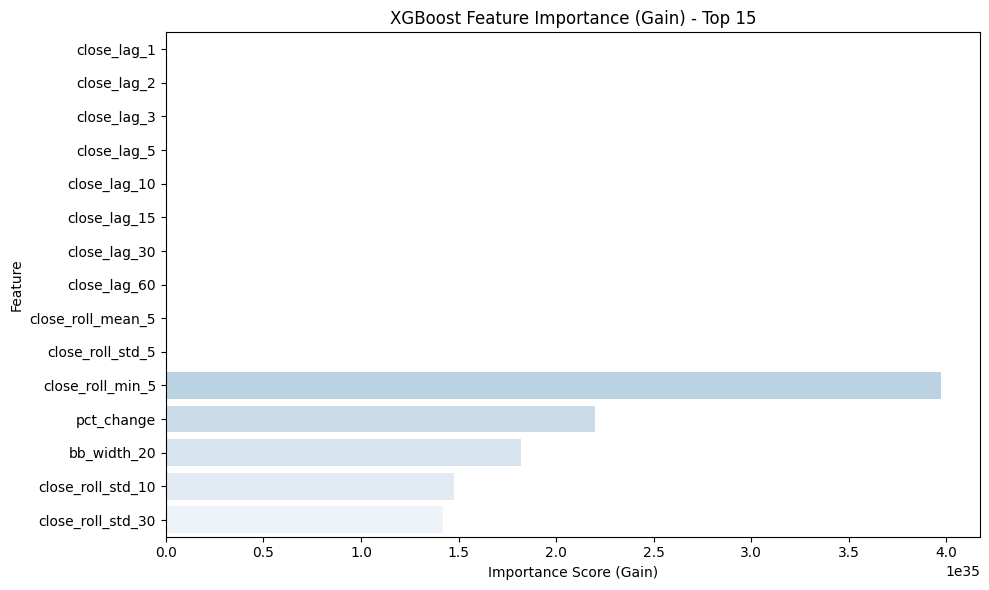

In [33]:
importance = xgb_model.get_score(importance_type='gain')
# Map generic feature names back to column names
feat_imp = pd.DataFrame({
    'feature': [feature_cols[int(k[1:])] for k in importance.keys()],
    'importance_gain': list(importance.values())
})
feat_imp = feat_imp.sort_values(by='importance_gain', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance_gain', y='feature', data=feat_imp, palette='Blues_r')
plt.title('XGBoost Feature Importance (Gain) - Top 15')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


#### Summary

In [34]:
print('╔' + '═'*60 + '╗')
print('║  USD/CHF FOREX FORECASTING — FULL PIPELINE DONE             ║')
print('╠' + '═'*60 + '╣')
for n in names:
    print(f'║ {n:<10s} R²={metrics_df.loc[n, "r2"]:>8.4f} RMSE={metrics_df.loc[n, "rmse"]:.8f} DirAcc={metrics_df.loc[n, "diracc"]:.1f}% ║')
print('╠' + '═'*60 + '╣')
print(f'║  ★ BEST: XGBoost                                            ║')
print('╚' + '═'*60 + '╝')

╔════════════════════════════════════════════════════════════╗
║  USD/CHF FOREX FORECASTING — FULL PIPELINE DONE             ║
╠════════════════════════════════════════════════════════════╣
║ XGBoost    R²=-210443528005091716312625504909023772672.0000 RMSE=1897022194219107.00000000 DirAcc=46.0% ║
║ KNN        R²= -0.0082 RMSE=0.00013130 DirAcc=46.4% ║
║ MLP        R²= -1.8641 RMSE=0.00022131 DirAcc=46.2% ║
╠════════════════════════════════════════════════════════════╣
║  ★ BEST: XGBoost                                            ║
╚════════════════════════════════════════════════════════════╝
